# $\nu_{\tau}$ Investigation in the Dune Collaboration for Advanced Particle Physics Laboratory 2026 - NN Training
Author: Grzegorz Jędrzejowski \
Supervision: prof. Katarzyna Grzelak


# Includes

In [16]:
import os, sys, importlib
my_home = '/scratch1/gjedrzej/Lab'
os.chdir(my_home) #GJ path
sys.path.append(os.path.join(os.getcwd(), "python"))

In [ ]:
requirements_path = os.path.join(my_home, 'requirements.txt')

%pip install --upgrade pip #Pip 21.3+ is required
%pip install -r {requirements_path}

#you might need to restart the kernel after installing requirements

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

2026-04-27 11:47:36.764603: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 11:47:36.793109: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 11:47:36.843138: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 11:47:39.129370: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [18]:
import analysis.scripts.convert_full_nodebug as kg
importlib.reload(kg)

import analysis.scripts.convert_skwarek as sk
importlib.reload(sk)

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

import analysis.scripts.ml_functions as ml
importlib.reload(ml)


output_dir = 'analysis/processedData'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created directory: {output_dir}")

# File Paths

In [19]:
FilePath_all = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions.gtrac.root"
output_path_all = os.path.join(output_dir, 'data_all_tau.csv')

# Plotting Class Separation Hypothesis before data preprocessing
Histrogramy dla próbek wygenerowanych całościowo (0.5-30 GeV) z rozpadającym się Taonem

In [39]:
df_all = pd.read_csv(output_path_all)
df_all_CC = df_all[df_all['CCNC'] == 'CC']
df_all_NC = df_all[df_all['CCNC'] == 'NC']

# pf.plot_tau_energy(df_all, ALL=True) confirmed no taons in the dataset

dfs_preprocessed = [df_all, df_all_CC, df_all_NC]

--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---


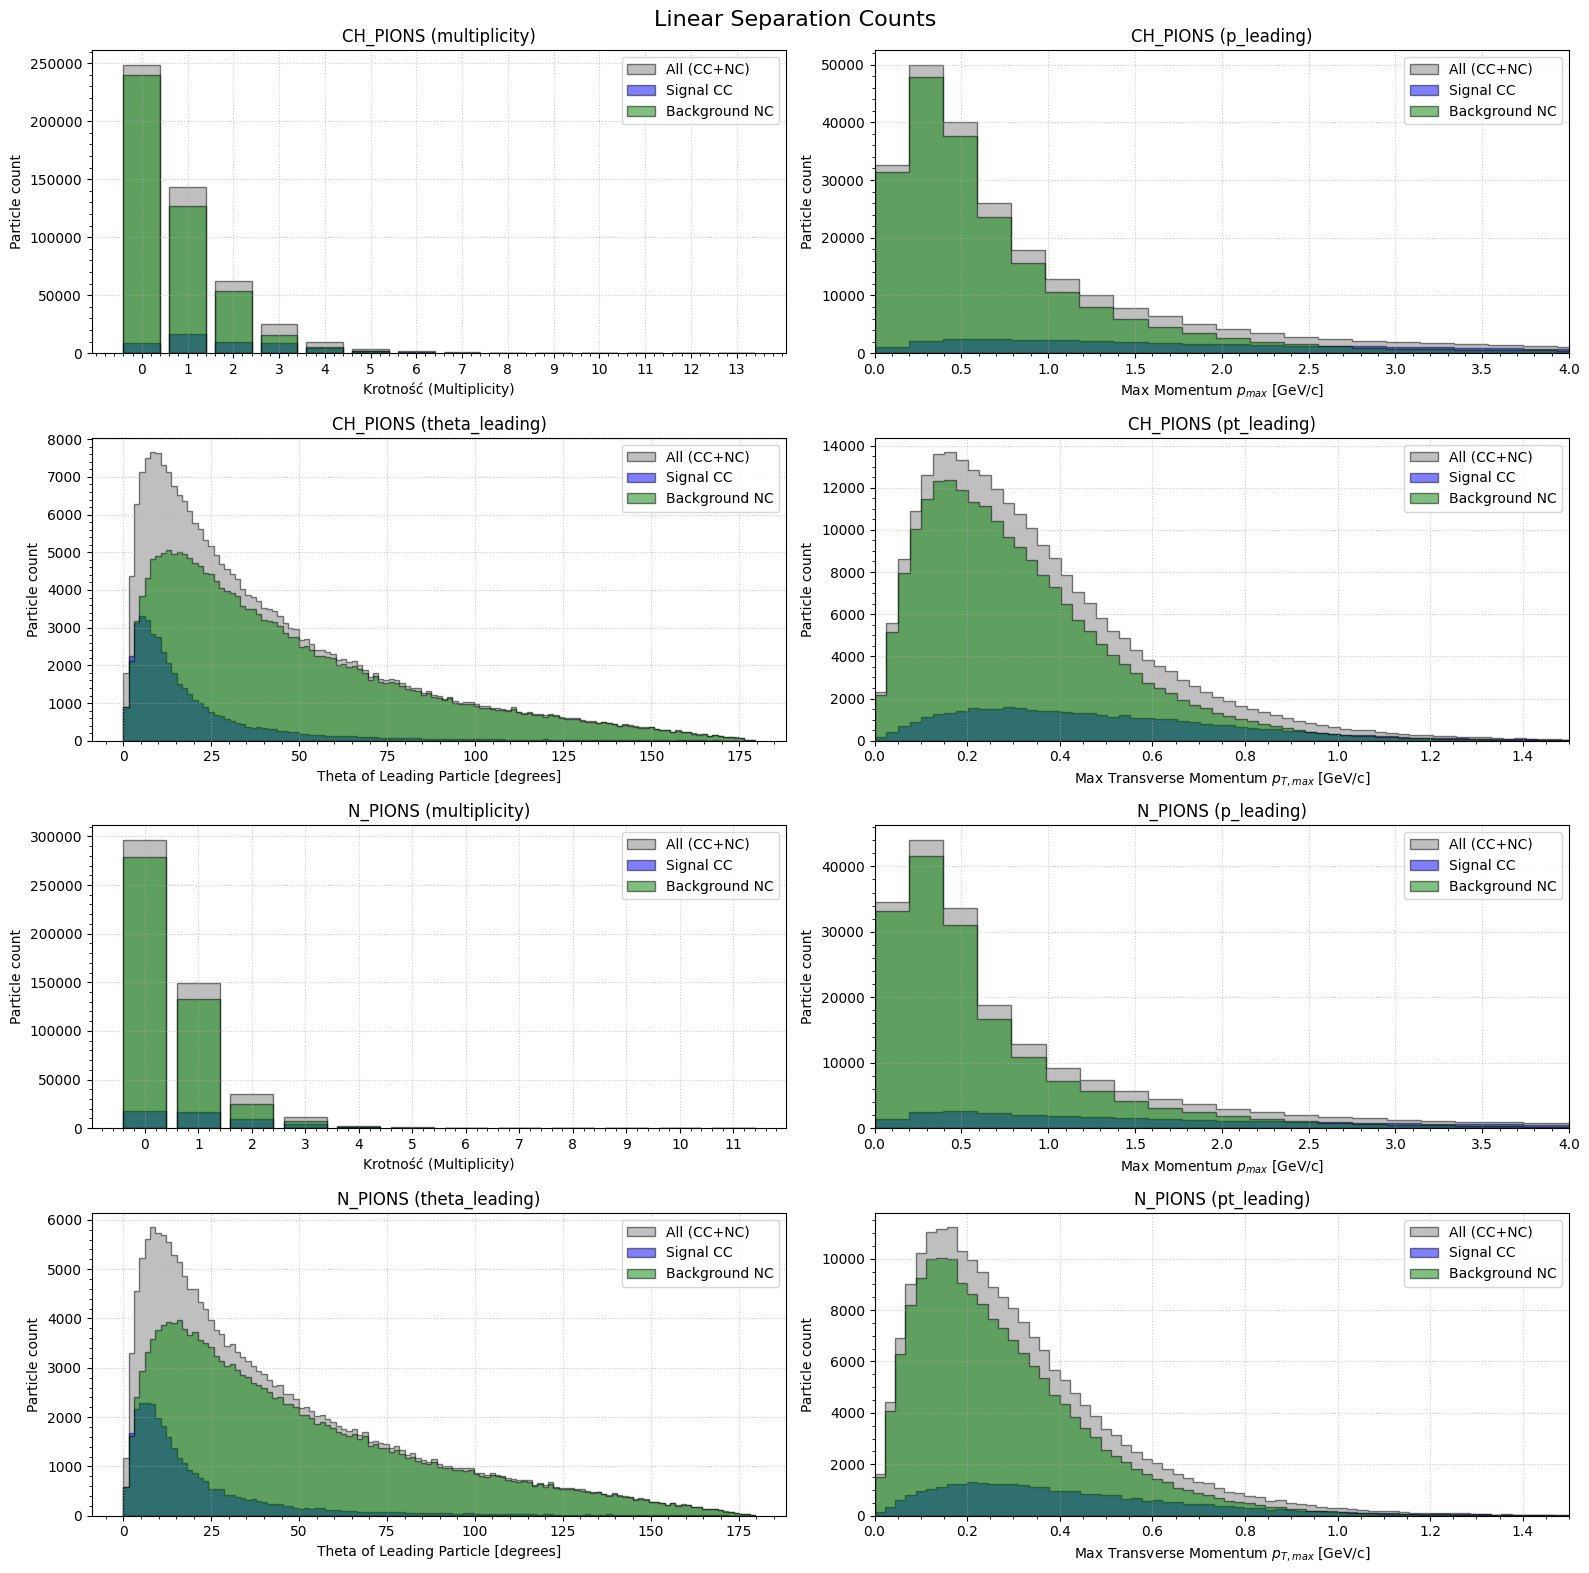

In [40]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[0, 1], density=False)
axes[0, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='theta_leading', ax=axes[1, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[1, 1], density=False)
axes[1, 1].set_xlim(0, 1.5) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[2, 1], density=False)
axes[2, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='theta_leading', ax=axes[3, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='pt_leading', ax=axes[3, 1], density=False)
axes[3, 1].set_xlim(0, 1.5) 

plt.suptitle("Linear Separation Counts", fontsize=16)
plt.tight_layout()
plt.show()

--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---


--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---


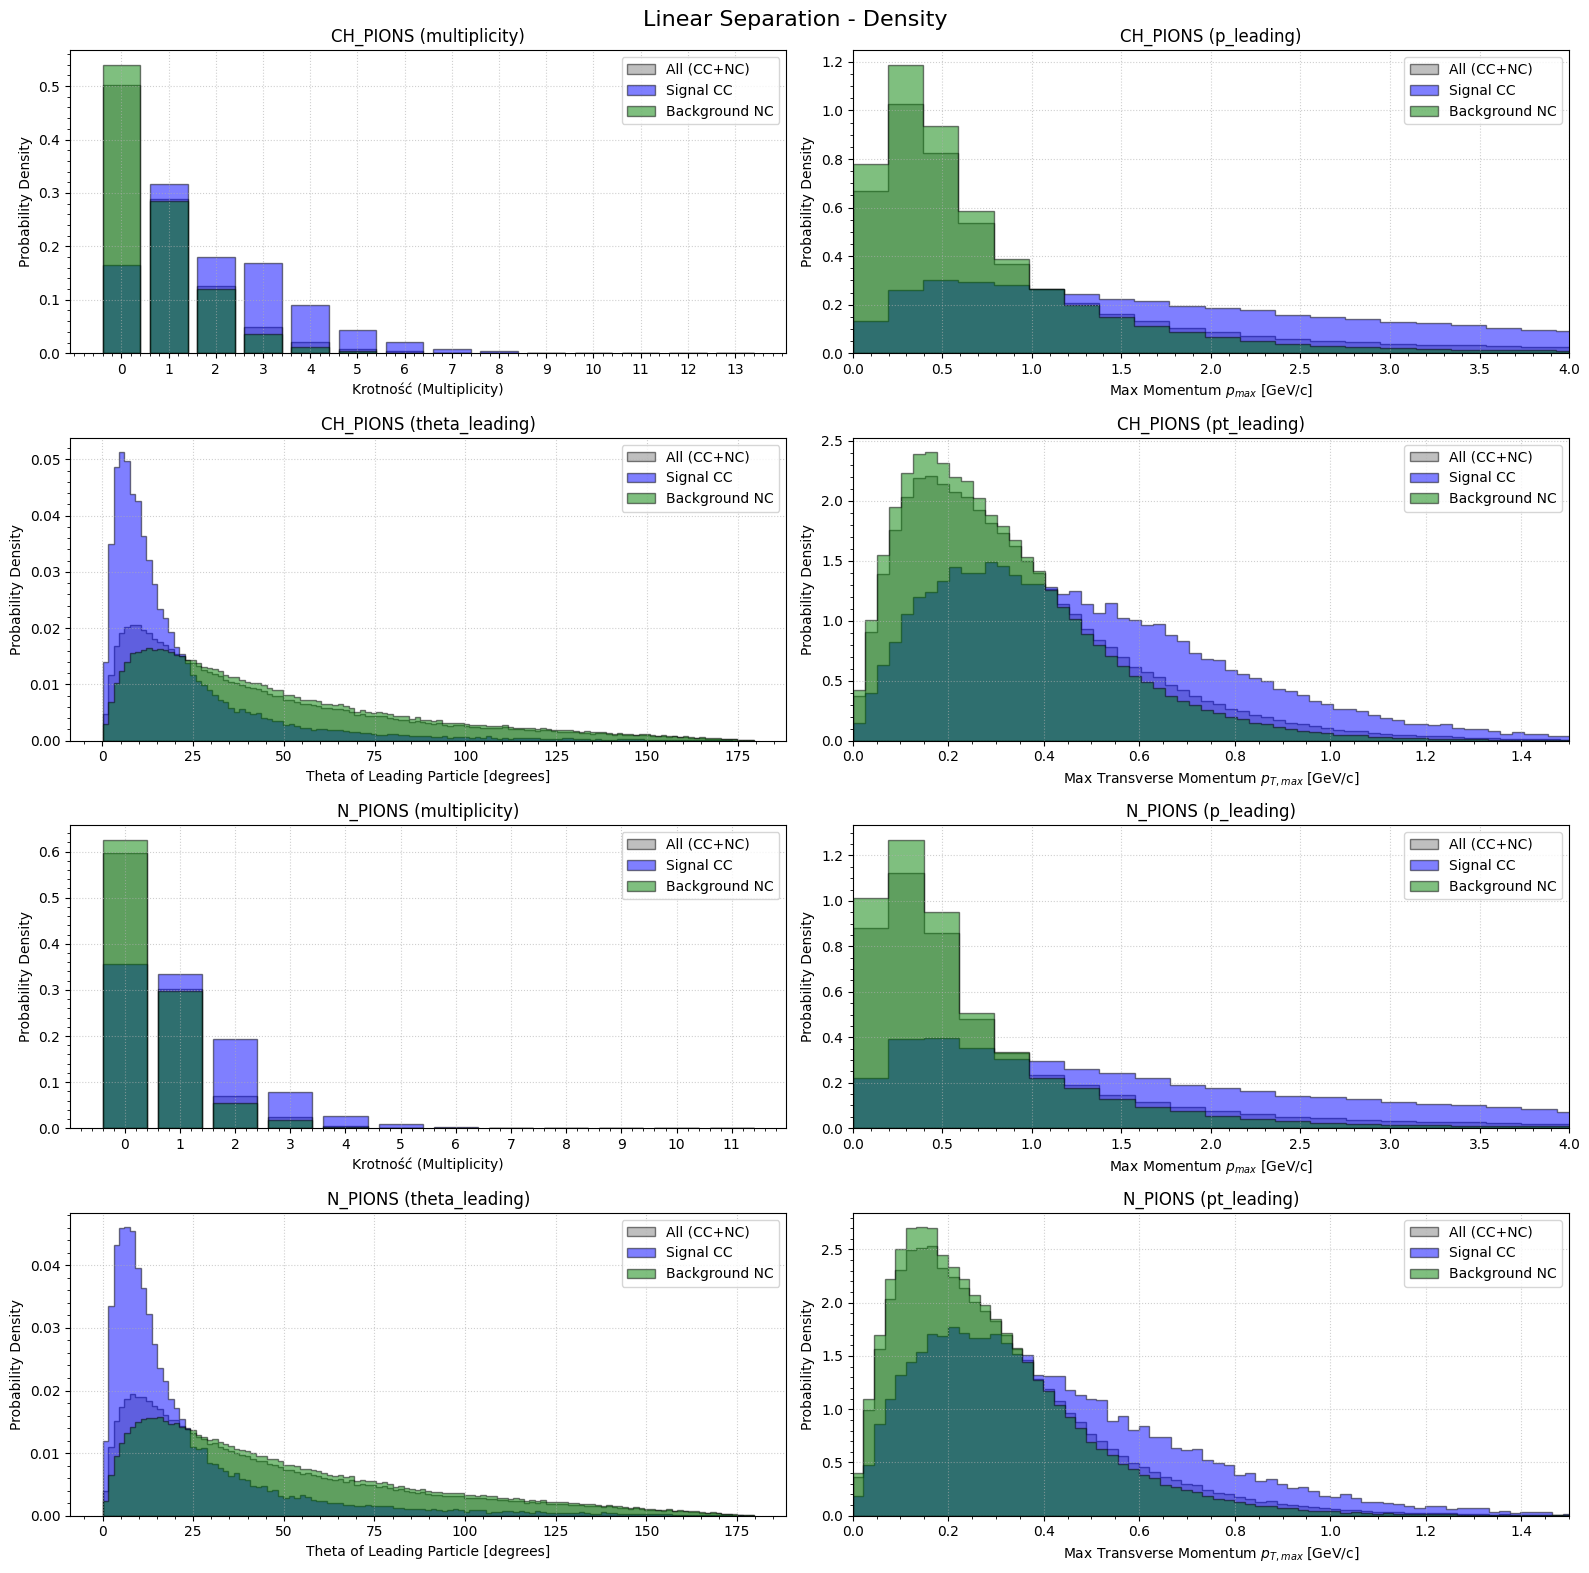

In [41]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[0, 1], density=True)
axes[0, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='theta_leading', ax=axes[1, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[1, 1], density=True)
axes[1, 1].set_xlim(0, 1.5) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[2, 1], density=True)
axes[2, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='theta_leading', ax=axes[3, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='pt_leading', ax=axes[3, 1], density=True)
axes[3, 1].set_xlim(0, 1.5) 

plt.suptitle("Linear Separation - Density", fontsize=16)
plt.tight_layout()
plt.show()

## Data Preprocess

In [ ]:
#features:
# ch pions multiplicity, leading p, leading theta, leading pt - 4
# n pions multiplicity, leading p, leading theta - 3

#labels:
# CC vs NC

In [52]:
import analysis.scripts.ml_functions as ml
importlib.reload(ml)
#take the data we analyzed above
FilePath_all = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions.gtrac.root"
output_path_all = os.path.join(output_dir, 'data_all_tau.csv')
df_all = pd.read_csv(output_path_all)

df_balanced = ml.get_balanced_subset(df_all, cc_per_type=25, nc_per_type=25)
test_data = ml.preProcess_data(df_balanced)


--- Subset Created: 200 events ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---


# Plotting Class Separation Hypothesis AFTER data preprocessing
Histrogramy dla próbek wygenerowanych całościowo (0.5-30 GeV) z rozpadającym się Taonem

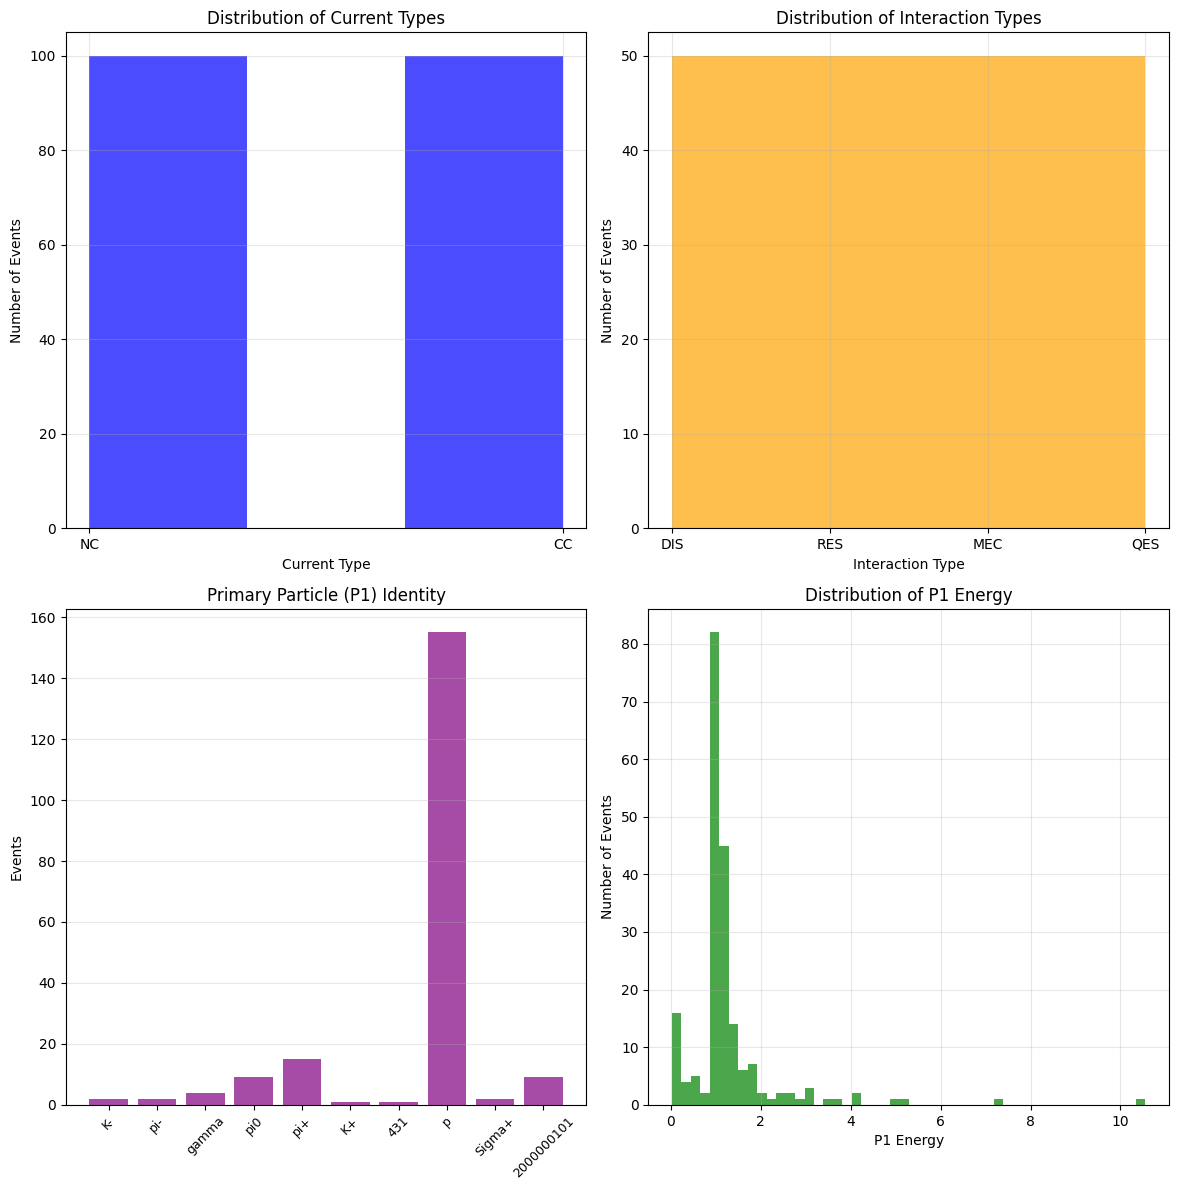

In [53]:
df_all = df_balanced
df_all_CC = df_all[df_all['CCNC'] == 'CC']
df_all_NC = df_all[df_all['CCNC'] == 'NC']

dfs_processed = [df_all, df_all_CC, df_all_NC]

pf.visualize_kg(df_balanced)

--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---


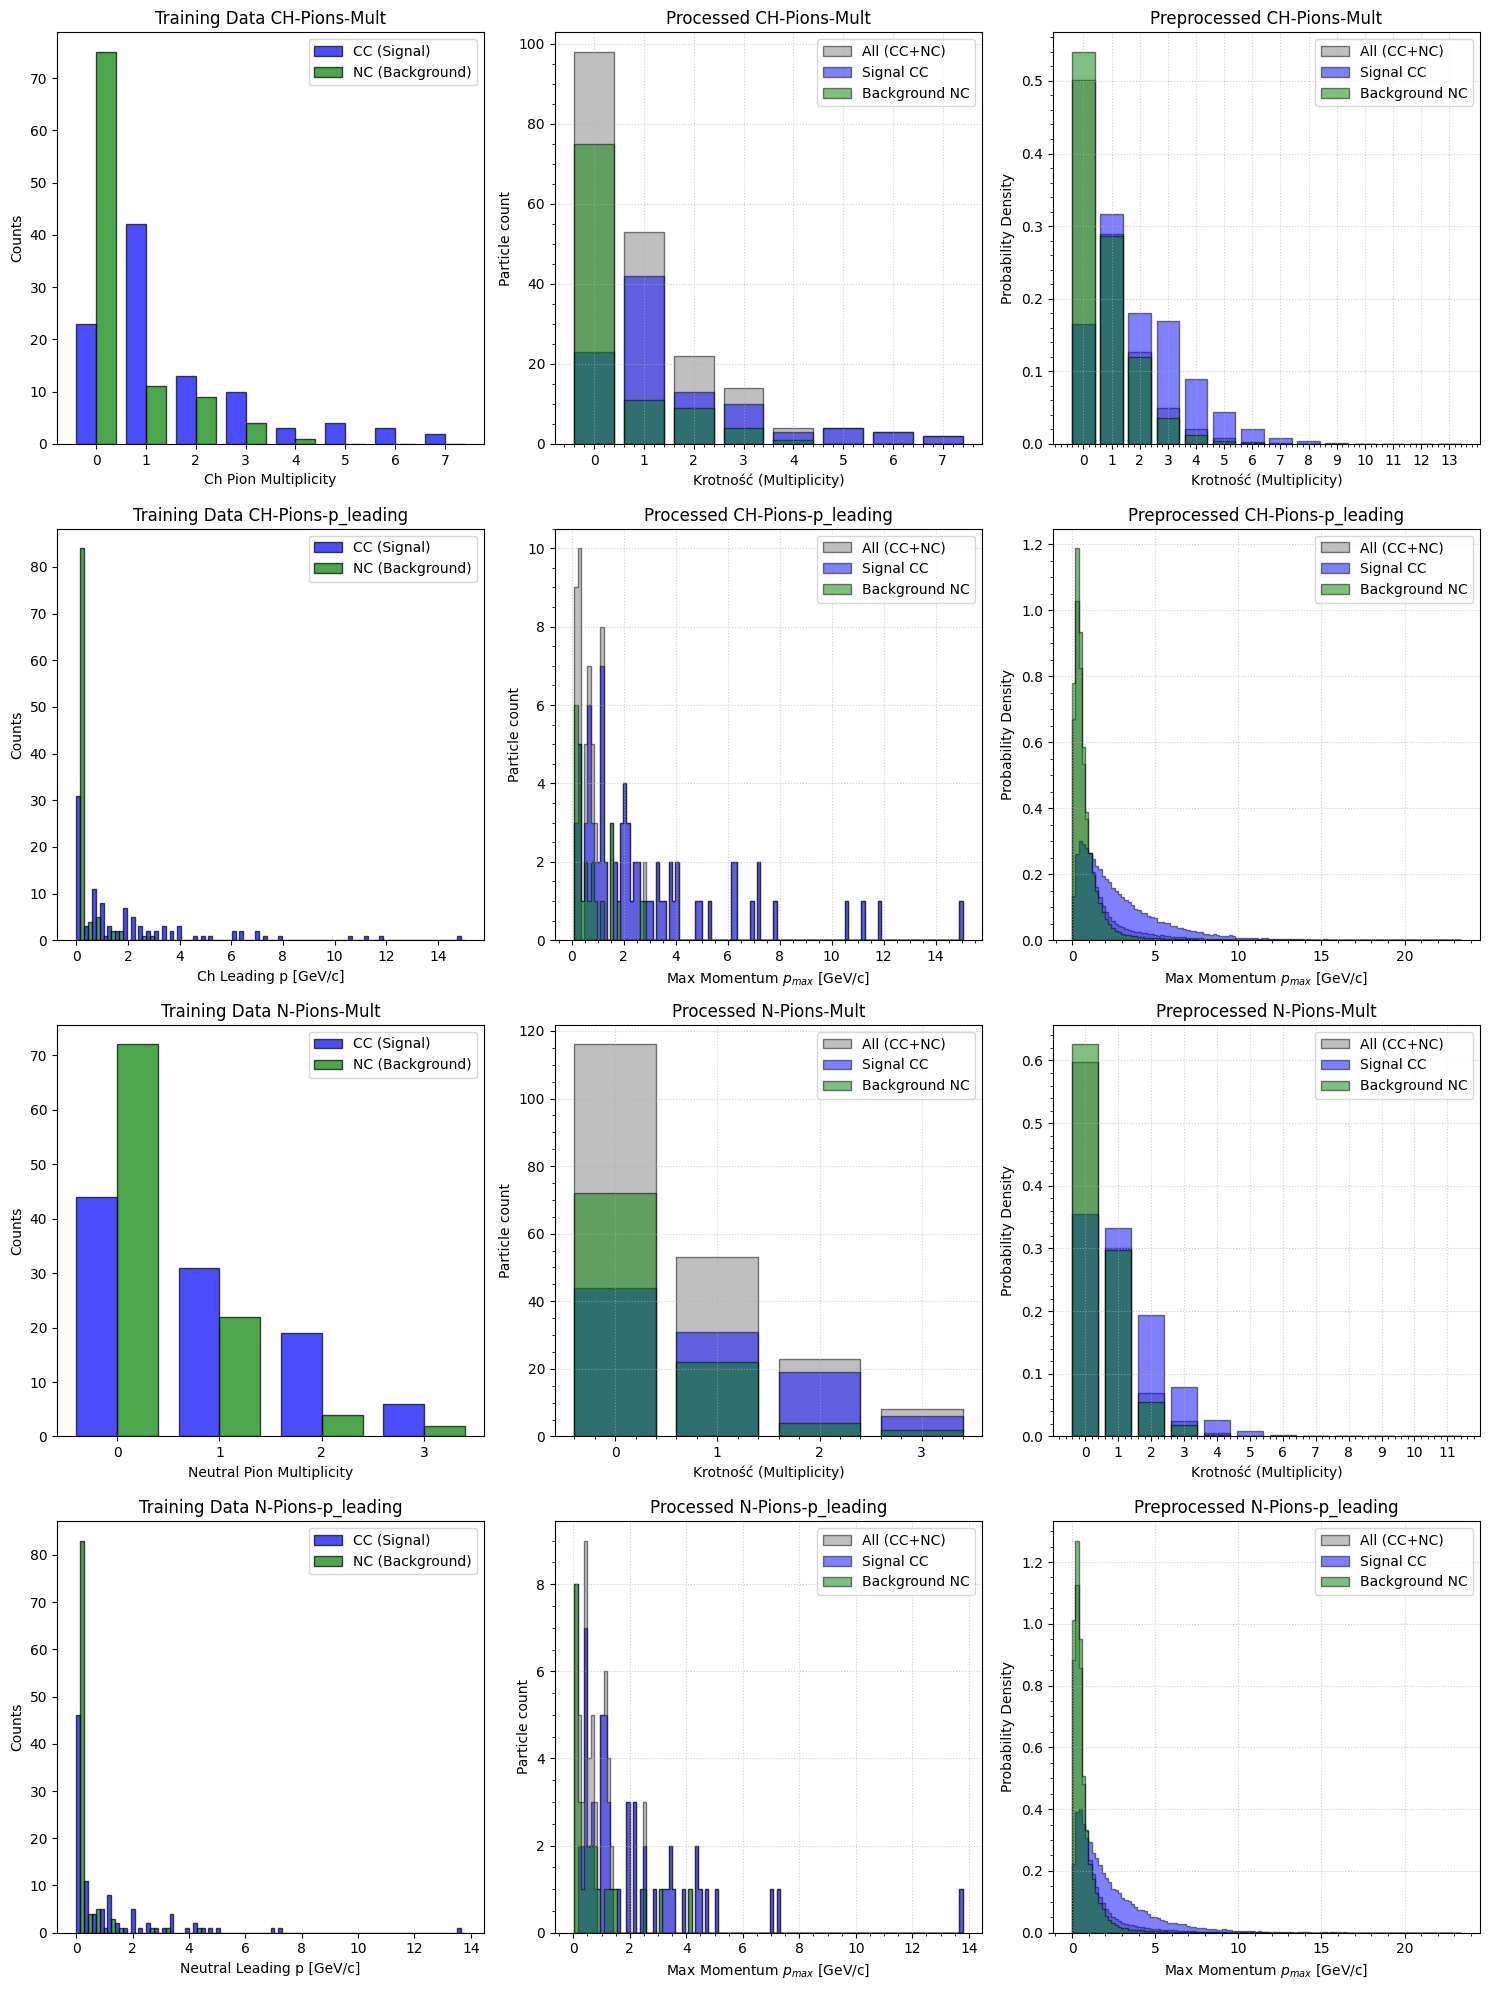

2026-04-27 12:56:34.753594: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-27 12:56:37.366509: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-27 12:56:40.205368: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-27 12:56:41.968314: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [54]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)



fig, axes = plt.subplots(4, 3, figsize=(15, 20))

pf.plot_feature_from_dataset(test_data, 0, ax=axes[0, 0]) 
axes[0,0].set_title("Training Data CH-Pions-Mult")    
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='multiplicity', ax=axes[0, 1], density=False)
axes[0,1].set_title("Processed CH-Pions-Mult")    
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 2], density=True)
axes[0,2].set_title("Preprocessed CH-Pions-Mult")    

pf.plot_feature_from_dataset(test_data, 1, ax=axes[1, 0]) 
axes[1,0].set_title("Training Data CH-Pions-p_leading")    
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='p_leading', ax=axes[1, 1], density=False)
axes[1,1].set_title("Processed CH-Pions-p_leading")    
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[1, 2], density=True)
axes[1,2].set_title("Preprocessed CH-Pions-p_leading")    

pf.plot_feature_from_dataset(test_data, 4, ax=axes[2, 0]) # Neutral Multiplicity
axes[2,0].set_title("Training Data N-Pions-Mult")
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='multiplicity', ax=axes[2, 1], density=False)
axes[2,1].set_title("Processed N-Pions-Mult")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 2], density=True)
axes[2,2].set_title("Preprocessed N-Pions-Mult")

pf.plot_feature_from_dataset(test_data, 5, ax=axes[3, 0]) # Neutral Leading p
axes[3,0].set_title("Training Data N-Pions-p_leading")
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='p_leading', ax=axes[3, 1], density=False)
axes[3,1].set_title("Processed N-Pions-p_leading")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[3, 2], density=True)
axes[3,2].set_title("Preprocessed N-Pions-p_leading")

# axes[3, 1].axis('off')
plt.tight_layout()
plt.show()

## Model

In [ ]:
# we trust the data
# put it into simple CNN
# train CNN
# eval training 


## Training

## Evaluation